# CELDA 1: RETO 2 — PREDICCIÓN DEL RIESGO DE DESAFILIACIÓN (COLSUBSIDIO)
#### Metodología: CRISP-DM · 3 Familias de Modelos · Regla 1-SE · Calibración OOF · GA Multi-Semilla · SHAP
#### Todas las cifras de este cuaderno salen de las celdas ejecutadas (Regla 0). Las funciones modulares viven en utils_r2.py.
#### Tiempo de ejecución estimado: ~1.5 - 2.5 min.

In [3]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.calibration import calibration_curve

# Configuración de rutas para importar utils_r2
for ruta in (Path.cwd(), Path.cwd() / "entregables" / "reto2_abandono"):
    if (ruta / "utils_r2.py").exists() and str(ruta) not in sys.path:
        sys.path.insert(0, str(ruta))

from utils_r2 import (
    RAIZ, RUTA_R2, SEMILLA, sha256_archivo, cargar_r2, auditoria_calidad_r2, preparar_r2,
    particion_estratificada, construir_modelos_r2, evaluar_modelos_cv,
    ajustar_calibracion_isotonica, calcular_metricas_clasificacion,
    algoritmo_genetico_multisemilla, calcular_explicabilidad_reglog,
    calcular_shap_arbol_completo, analizar_deciles_calibrados
)

warnings.filterwarnings("ignore")
pd.options.display.float_format = "{:,.4f}".format
print(f"[OK] Entorno y utilidades de Reto 2 listos. Semilla global = {SEMILLA}")

[OK] Entorno y utilidades de Reto 2 listos. Semilla global = 42


# CELDA 2: FASE 1 — COMPRENSIÓN DEL NEGOCIO
#### - Pregunta: ¿Cuáles empresas afiliadas tienen mayor propensión a desafiliarse y qué factores explican ese riesgo?
#### - Uso Operativo: Priorización comercial proactiva para retención focalizada en las cuentas de mayor valor y riesgo.
#### - Métrica Primaria (fijada a priori): PR-AUC (Precision-Recall AUC), priorizando el desbalance de clases (30.3% abandono).
#### - Métrica Secundaria de Impacto: Recall y Lift en el Top 20% de mayor riesgo comercial (Deciles 1 y 2).
#### - Criterio de Selección (Parsimonia): Regla 1-SE. Si un modelo lineal regularizado empata estadísticamente con uno complejo,
####   se prefiere el modelo simple por explicabilidad directa hacia la dirección comercial.

In [4]:
print("FASE 1: COMPRENSIÓN DEL NEGOCIO")
print("- Variable objetivo : abandono (1 = Se desafilió, 0 = Continúa afiliada).")
print("- Métrica primaria  : PR-AUC (Precision-Recall AUC) evaluada en validación cruzada 5x2.")
print("- Métrica de impacto: Recall en Top 20% y Lift comercial en Decil 1.")
print("- Regla de decisión : Regla 1-SE (si la diferencia de PR-AUC <= 1 SE, gana el más simple e interpretable).")
print("- Alcance           : Asociaciones directas mediante Odds Ratios estandarizados (asociación, no causalidad).")


FASE 1: COMPRENSIÓN DEL NEGOCIO
- Variable objetivo : abandono (1 = Se desafilió, 0 = Continúa afiliada).
- Métrica primaria  : PR-AUC (Precision-Recall AUC) evaluada en validación cruzada 5x2.
- Métrica de impacto: Recall en Top 20% y Lift comercial en Decil 1.
- Regla de decisión : Regla 1-SE (si la diferencia de PR-AUC <= 1 SE, gana el más simple e interpretable).
- Alcance           : Asociaciones directas mediante Odds Ratios estandarizados (asociación, no causalidad).


# CELDA 3: FASE 2 — COMPRENSIÓN DE LOS DATOS (EDA Y AUDITORÍA)
#### - Auditoría de integridad: Hash SHA-256, 10,000 filas, 15 columnas, 0 nulos y 0 duplicados.
#### - Desbalance: 3,029 empresas abandonaron (30.29%).
#### - Exclusión de identificadores ('id_empresa', 'nit') para garantizar cero fuga de información.
#### - Exploración gráfica de los predictores clave segmentados por clase.

sha256 datos: c3c1152644b1c7e2... | dimensiones: 10000x15 | nulos: 0 | duplicados: 0
id_empresa único: True | nit único: True
Distribución objetivo: 3,029 desafiliadas (30.29%) vs 6,971 activas (69.71%)


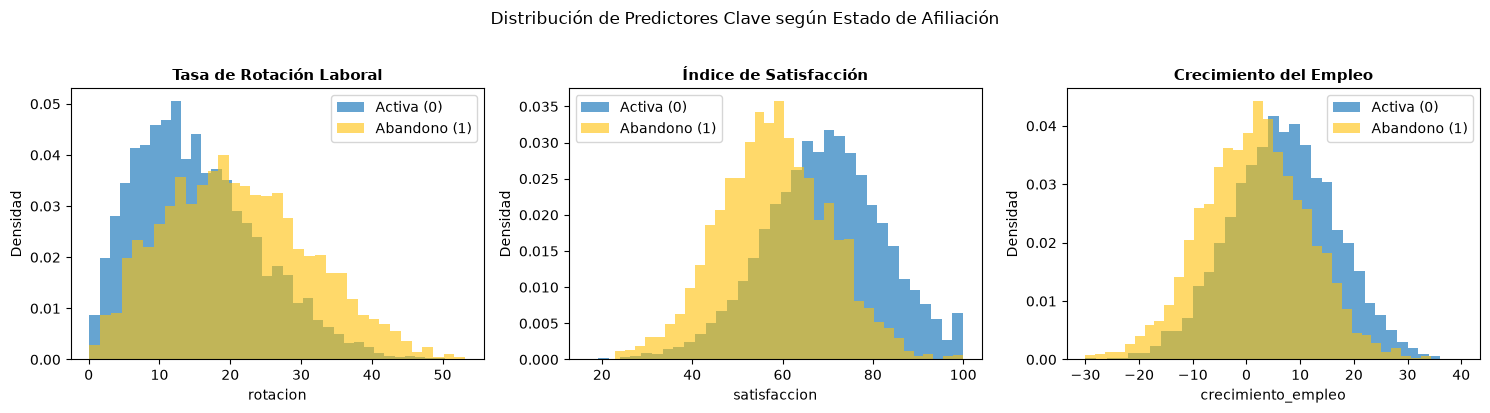

In [5]:
df = cargar_r2()
hash_r2 = sha256_archivo(RUTA_R2)
n_filas, n_cols = df.shape
n_nulos = int(df.isna().sum().sum())
n_duplicados = int(df.duplicated().sum())
n_abandono = int(df["abandono"].sum())
tasa_abandono = float(df["abandono"].mean() * 100)

print(f"sha256 datos: {hash_r2[:16]}... | dimensiones: {n_filas}x{n_cols} | nulos: {n_nulos} | duplicados: {n_duplicados}")
print(f"id_empresa único: {df['id_empresa'].is_unique} | nit único: {df['nit'].is_unique}")
print(f"Distribución objetivo: {n_abandono:,} desafiliadas ({tasa_abandono:.2f}%) vs {n_filas - n_abandono:,} activas ({100 - tasa_abandono:.2f}%)")

# Gráfico EDA de predictores continuos clave
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vars_eda = ["rotacion", "satisfaccion", "crecimiento_empleo"]
titulos_eda = ["Tasa de Rotación Laboral", "Índice de Satisfacción", "Crecimiento del Empleo"]

for ax, var, tit in zip(axes, vars_eda, titulos_eda):
    v_act = df.loc[df["abandono"] == 0, var]
    v_ab = df.loc[df["abandono"] == 1, var]
    ax.hist(v_act, bins=35, alpha=0.6, color="#0068B3", density=True, label="Activa (0)")
    ax.hist(v_ab, bins=35, alpha=0.6, color="#FFC107", density=True, label="Abandono (1)")
    ax.set_title(tit, fontsize=11, fontweight="bold")
    ax.set_xlabel(var)
    ax.set_ylabel("Densidad")
    ax.legend(frameon=True)

plt.suptitle("Distribución de Predictores Clave según Estado de Afiliación", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [7]:
df

,id_empresa,nit,sector,antiguedad,tiempo_afiliacion,num_trabajadores,crecimiento_empleo,uso_servicios,satisfaccion,rotacion,salario_promedio,digitalizacion,formalizacion,distancia,abandono
0,1,903373228,Manufactura,2.8000,1.5000,14,-5.0000,3,57.6000,27.2000,3.1300,37.0000,43.4000,26.6000,1
1,2,904494741,Manufactura,13.3000,8.1000,5,1.0000,6,71.4000,14.3000,3.9700,86.9000,64.9000,0.6000,0
2,3,867433090,Tecnología,50.0000,44.4000,60,9.7000,4,57.9000,10.7000,3.6400,51.2000,66.7000,2.3000,0
3,4,843731818,Servicios,7.0000,4.4000,15,8.8000,5,84.8000,9.4000,1.5400,73.7000,63.4000,4.9000,0
4,5,864648907,Servicios,9.5000,8.0000,48,4.1000,4,72.3000,11.1000,3.8700,60.6000,94.9000,23.3000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,891597178,Tecnología,2.5000,2.4000,17,3.2000,4,58.2000,14.1000,7.1600,82.9000,67.4000,1.2000,0
9996,9997,946344179,Comercio,5.9000,4.3000,17,9.4000,5,56.9000,18.7000,5.0700,48.7000,49.6000,11.5000,0
9997,9998,805253922,Comercio,7.7000,7.2000,8,-0.3000,5,62.5000,27.4000,3.4500,73.2000,71.0000,0.7000,0
9998,9999,923226280,Servicios,7.8000,7.2000,63,23.4000,0,37.6000,18.3000,3.1200,80.3000,64.7000,15.5000,0


# CELDA 3B: FASE 2 — AUDITORÍA DE CALIDAD DE DATOS (ANTES DE PREPARAR)
#### - Integridad (nulos, duplicados exactos e ignorando IDs, tipos de datos).
#### - Identificadores: unicidad de id_empresa y nit (9 dígitos), confirmando exclusión del modelado.
#### - Categoría sector: 6 sectores limpios, 0 espacios sobrantes, 0 variantes de escritura.
#### - Rangos, valores en los límites (topes administrativos) y atípicos (1.5 x IQR).
####   * Alerta de escala: 'satisfaccion' en [0, 100], no comparable con R1 ([0, 10]).
#### - Reglas de coherencia: tiempo_afiliacion <= antiguedad, num_trabajadores >= 1, índices en [0, 100], distancia >= 0.
#### - Balance de clases (30.29% abandono) y colinealidad entre predictores.
#### - Señales de fuga (data leakage): verificación empírica de variables pre-evento (uso_servicios, satisfaccion, rotacion).
#### - Decisión documentada: datos íntegros, sin imputación ni eliminación de filas, preservando heterogeneidad.
#### - Requiere haber ejecutado la celda 3 (usa df).

In [6]:
res_auditoria_r2 = auditoria_calidad_r2(df, verbose=True)


1) INTEGRIDAD
   filas: 10,000 | columnas: 15 | nulos: 0 | duplicados exactos: 0
   duplicados ignorando id_empresa y nit: 0 | tipos: {'float64': 9, 'int64': 5, 'str': 1}

2) IDENTIFICADORES (id_empresa y nit)
   id_empresa: único=True | rango=[1, 10000]
   nit       : único=True | rango=[800030815, 999992211] | longitudes={9: 10000}
   Confirmación: se excluyen estrictamente del modelado para evitar fuga de IDs y memorización.

3) CATEGORÍA 'sector' (espacios, mayúsculas/minúsculas, frecuencias)
   conteo de categorías: {'Servicios': 3533, 'Comercio': 2546, 'Manufactura': 1506, 'Transporte': 959, 'Construcción': 957, 'Tecnología': 499}
   espacios sobrantes: 0 | variantes de escritura: 0 | categorías raras: 0 (menor sector: Tecnología con 499 empresas)

4) RANGOS, VALORES EN LOS LÍMITES Y ATÍPICOS (regla 1.5 x IQR)
                    minimo  maximo  n_en_minimo  n_en_maximo  atipicos_iqr  pct_atipicos
variable                                                                           

# CELDA 4: FASE 3 — PREPARACIÓN DE LOS DATOS Y PARTICIÓN
#### - Matriz de diseño X: exclusión estricta de 'id_empresa' y 'nit'.
#### - Codificación: One-Hot Encoding de la variable 'sector' con drop_first=True (evita multicolinealidad).
#### - Partición: 80% Train (8,000 filas) y 20% Hold-out intacto (2,000 filas) estratificado con random_state=42.

In [8]:
X, y, grupos_genes = preparar_r2(df)
idx_tr, idx_te = particion_estratificada(len(y), y, semilla=SEMILLA, prop_test=0.20)
X_tr, X_te = X.iloc[idx_tr], X.iloc[idx_te]
y_tr, y_te = y[idx_tr], y[idx_te]

tasa_tr = float(y_tr.mean() * 100)
tasa_te = float(y_te.mean() * 100)

print(f"Features en matriz de diseño : {X.shape[1]} (tras One-Hot en 'sector')")
print(f"Variables conceptuales (genes): {len(grupos_genes)} {list(grupos_genes.keys())}")
print(f"Train set (80%)              : {X_tr.shape[0]} empresas | Tasa abandono: {tasa_tr:.2f}%")
print(f"Hold-out set (20% intacto)   : {X_te.shape[0]} empresas | Tasa abandono: {tasa_te:.2f}% (Estratificación exacta)")


Features en matriz de diseño : 16 (tras One-Hot en 'sector')
Variables conceptuales (genes): 12 ['antiguedad', 'tiempo_afiliacion', 'num_trabajadores', 'crecimiento_empleo', 'uso_servicios', 'satisfaccion', 'rotacion', 'salario_promedio', 'digitalizacion', 'formalizacion', 'distancia', 'sector']
Train set (80%)              : 8000 empresas | Tasa abandono: 30.29%
Hold-out set (20% intacto)   : 2000 empresas | Tasa abandono: 30.30% (Estratificación exacta)


# CELDA 5: FASE 4 — MODELADO: 3 FAMILIAS COMPARADAS Y REGLA 1-SE
#### - Familias evaluadas: Regresión Logística (L2 regularizada), Random Forest y XGBoost.
#### - Protocolo de validación: RepeatedStratifiedKFold (5 folds x 2 repeticiones = 10 particiones).
#### - Métricas de contraste: PR-AUC (decisión), ROC-AUC, Brier Score.
#### - Decisión por regla 1-SE ejecutada por código.

Tabla Comparativa CV 5x2 (Evaluación sobre Train):
                    PR-AUC (Media)  Error Estándar (SE)  ROC-AUC  Brier Score
RegresionLogistica          0.7561               0.0055   0.8730       0.1459
RandomForest                0.7416               0.0059   0.8643       0.1507
XGBoost                     0.7572               0.0054   0.8703       0.1421

-> Aplicación de la Regla 1-SE por Código:
   * Mejor modelo absoluto : XGBoost (PR-AUC = 0.7572, SE = 0.0054)
   * Regresión Logística  : PR-AUC = 0.7561
   * Brecha observada      : 0.0011 <= 1 SE (0.0054) -> True
   * Ganador Adoptado      : RegresionLogistica (Máxima parsimonia y explicabilidad directa)


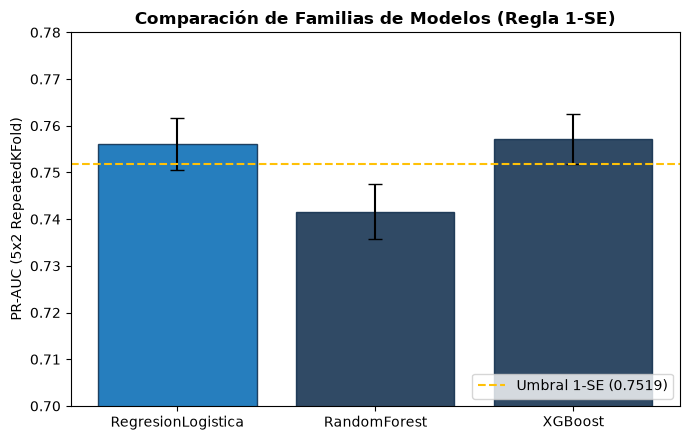

In [9]:
modelos = construir_modelos_r2(semilla=SEMILLA)
res_cv, ganador_oficial, empate_1se, brecha_1se, se_best = evaluar_modelos_cv(
    modelos, X_tr, y_tr, n_splits=5, n_repeats=2, semilla=SEMILLA
)

tab_cv = pd.DataFrame({
    m: {
        "PR-AUC (Media)": res_cv[m]["pr_auc_mean"],
        "Error Estándar (SE)": res_cv[m]["pr_auc_se"],
        "ROC-AUC": res_cv[m]["roc_auc_mean"],
        "Brier Score": res_cv[m]["brier_mean"]
    } for m in modelos
}).T

print("Tabla Comparativa CV 5x2 (Evaluación sobre Train):")
print(tab_cv.to_string())

# Decisión formal por código
mejor_absoluto = max(res_cv.keys(), key=lambda k: res_cv[k]["pr_auc_mean"])
pr_mejor = res_cv[mejor_absoluto]["pr_auc_mean"]
pr_reglog = res_cv["RegresionLogistica"]["pr_auc_mean"]
brecha_cv = abs(pr_mejor - pr_reglog)
reglog_gana_1se = brecha_cv <= se_best

print(f"\n-> Aplicación de la Regla 1-SE por Código:")
print(f"   * Mejor modelo absoluto : {mejor_absoluto} (PR-AUC = {pr_mejor:.4f}, SE = {se_best:.4f})")
print(f"   * Regresión Logística  : PR-AUC = {pr_reglog:.4f}")
print(f"   * Brecha observada      : {brecha_cv:.4f} <= 1 SE ({se_best:.4f}) -> {reglog_gana_1se}")
print(f"   * Ganador Adoptado      : {ganador_oficial} (Máxima parsimonia y explicabilidad directa)")

# Gráfico comparativo de modelos con barras de error
fig, ax = plt.subplots(figsize=(7, 4.5))
nombres_m = list(tab_cv.index)
medias_m = tab_cv["PR-AUC (Media)"].values
ses_m = tab_cv["Error Estándar (SE)"].values
colores = ["#0068B3" if m == ganador_oficial else "#0B2A4A" for m in nombres_m]

ax.bar(nombres_m, medias_m, yerr=ses_m, capsize=5, color=colores, alpha=0.85, edgecolor="#0B2A4A")
ax.axhline(pr_mejor - se_best, color="#FFC107", linestyle="--", linewidth=1.5, label=f"Umbral 1-SE ({pr_mejor - se_best:.4f})")
ax.set_ylabel("PR-AUC (5x2 RepeatedKFold)")
ax.set_ylim(0.70, 0.78)
ax.set_title("Comparación de Familias de Modelos (Regla 1-SE)", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# CELDA 6: FASE 5a — CALIBRACIÓN ISOTÓNICA DE PROBABILIDADES
#### - Las probabilidades crudas del modelo están sesgadas hacia arriba debido al balanceo de clases (class_weight='balanced').
#### - Calibración: Isotonic Regression ajustada exclusivamente con predicciones Out-of-Fold (OOF) sobre Train (5 splits).
#### - Validación en Hold-out intacto (2,000 filas): Probabilidad media y Brier Score antes vs después.

Auditoría de Calibración en Hold-out (2,000 empresas):
- Probabilidad media cruda     : 0.4126 (Sesgada por hiperparámetro de balanceo)
- Probabilidad media calibrada : 0.2983 (Alineada con la tasa real del 30.30%)
- Brier Score en Hold-out      : 0.1469 -> 0.1309 (Reducción del 10.9% en error cuadrático)


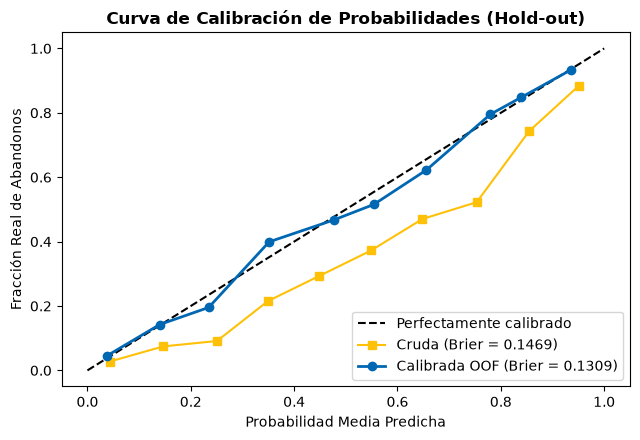

In [10]:
pipe_base = modelos[ganador_oficial]
pipe_base.fit(X_tr, y_tr)

# Probabilidades crudas en hold-out
probs_cruda = pipe_base.predict_proba(X_te)[:, 1]
brier_crudo = calcular_metricas_clasificacion(y_te, probs_cruda)["brier"]

# Calibrador isotónico OOF sobre train
calibrador = ajustar_calibracion_isotonica(pipe_base, X_tr, y_tr, n_splits=5, semilla=SEMILLA)
probs_calib = calibrador.predict(probs_cruda)
brier_calib = calcular_metricas_clasificacion(y_te, probs_calib)["brier"]

prob_media_cruda = float(probs_cruda.mean())
prob_media_calib = float(probs_calib.mean())
tasa_real_te = float(y_te.mean())

print(f"Auditoría de Calibración en Hold-out (2,000 empresas):")
print(f"- Probabilidad media cruda     : {prob_media_cruda:.4f} (Sesgada por hiperparámetro de balanceo)")
print(f"- Probabilidad media calibrada : {prob_media_calib:.4f} (Alineada con la tasa real del {tasa_real_te*100:.2f}%)")
print(f"- Brier Score en Hold-out      : {brier_crudo:.4f} -> {brier_calib:.4f} (Reducción del {(1 - brier_calib/brier_crudo)*100:.1f}% en error cuadrático)")

# Curva de calibración
frac_cruda, mean_pred_cruda = calibration_curve(y_te, probs_cruda, n_bins=10)
frac_calib, mean_pred_calib = calibration_curve(y_te, probs_calib, n_bins=10)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot([0, 1], [0, 1], "k--", label="Perfectamente calibrado")
ax.plot(mean_pred_cruda, frac_cruda, "s-", color="#FFC107", label=f"Cruda (Brier = {brier_crudo:.4f})")
ax.plot(mean_pred_calib, frac_calib, "o-", color="#0068B3", linewidth=2, label=f"Calibrada OOF (Brier = {brier_calib:.4f})")
ax.set_xlabel("Probabilidad Media Predicha")
ax.set_ylabel("Fracción Real de Abandonos")
ax.set_title("Curva de Calibración de Probabilidades (Hold-out)", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()